# Лабораторная работа 1.

### Воробьев Андрей 465440 J3211
### Шакина Анна ЛЕНЬИСКАТЬ J3211

Выберите датасет, в котором есть атрибут, который «хочется предсказывать» (неважно, бинарный, категориальный или количественный он). Предварительно обработайте данные (разобраться с пропусками и т.п.). Разбейте выборку на обучающую и тестовую (можно «наивным» способом, хоть кроссвалидация действительно имеет место быть).

Выявите статистически значимые факторы (сначала можно порисовать картинки, потом провести стат. тесты)
Обучите какую-нибудь ML-модель на выявленных статистически значимых факторах
Посмотрите, как оно работает на тестовой выборки

Задание звучит довольно-таки творчески, так что приведём конкретные требования, исходя из которых будет оцениваться само решение:

Описана в общих чертах ML-модель или приведена ссылка на документацию/статью, откуда брали ML-модель.
Для ML-модели выводится значение функции потерь на обучающей и тестовой выборках (вывод других метрик качества опционален).
Как минимум два теста реализованы самостоятельно, причем должны выводиться статистика критерия, p-value, области принятия и критическая области. Минимальное количество уникальных применений стат. тестов — 4 (среди них 2 вызова самостоятельно реализованных тестов)
Нужно выявить хотя бы 1 статистически значимый фактор.

![oppossum](https://cdn.wmnf.org/wp-content/uploads/2022/06/Flower-Baby-7x7-1-1024x1024.jpg)

## Скачивание данных

In [137]:
# import kagglehub
#
# path = kagglehub.dataset_download("abrambeyer/openintro-possum")
#
# print(path)

## Импорты

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy import stats

## Датасет

In [139]:
# Загрузим датасет
data = pd.read_csv(r'C:\Users\Professional\.cache\kagglehub\datasets\abrambeyer\openintro-possum\versions\1\possum.csv')
data.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [140]:
# Проверим наличие пропусков
print(data.isnull().sum())

case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64


In [141]:
# Два пропуска в возрасте и один пропуск в длине ноги
# Заполним пропуски медианой
data['age'] = data['age'].fillna(data['age'].median())
data['footlgth'] = data['footlgth'].fillna(data['footlgth'].median())
print(data.isnull().sum())

case        0
site        0
Pop         0
sex         0
age         0
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    0
earconch    0
eye         0
chest       0
belly       0
dtype: int64


In [142]:
# Удалим колонки 'site' и 'Pop', так как не являются классами в зависимости от места обитания, что не является интересным для нашей задачи на данном этапе
# Также удалим колонку 'case', так как она не несет полезной информации для модели
data = data.drop(['site', 'Pop', 'case'], axis=1)

In [143]:
# Разделим выборку на обучающую и тестовую
# Целевая переменная - длина головы (hdlngth)
X = data.drop('hdlngth', axis=1)
y = data['hdlngth']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=465440)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(83, 10) (21, 10) (83,) (21,)


## Анализ данных

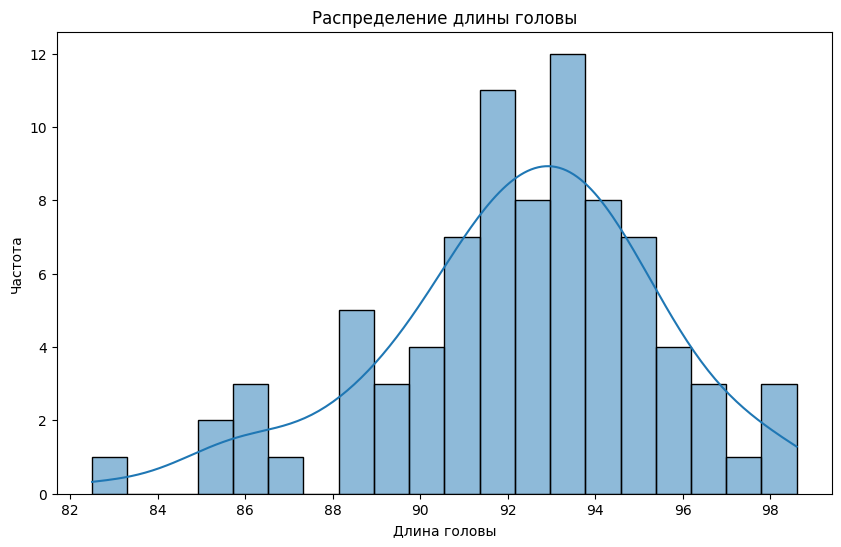

In [148]:
# Посмотрим на распределение длины головы
plt.figure(figsize=(10, 6))
sns.histplot(y_train, bins=20, kde=True)
plt.title('Распределение длины головы')
plt.xlabel('Длина головы')
plt.ylabel('Частота')
plt.show()

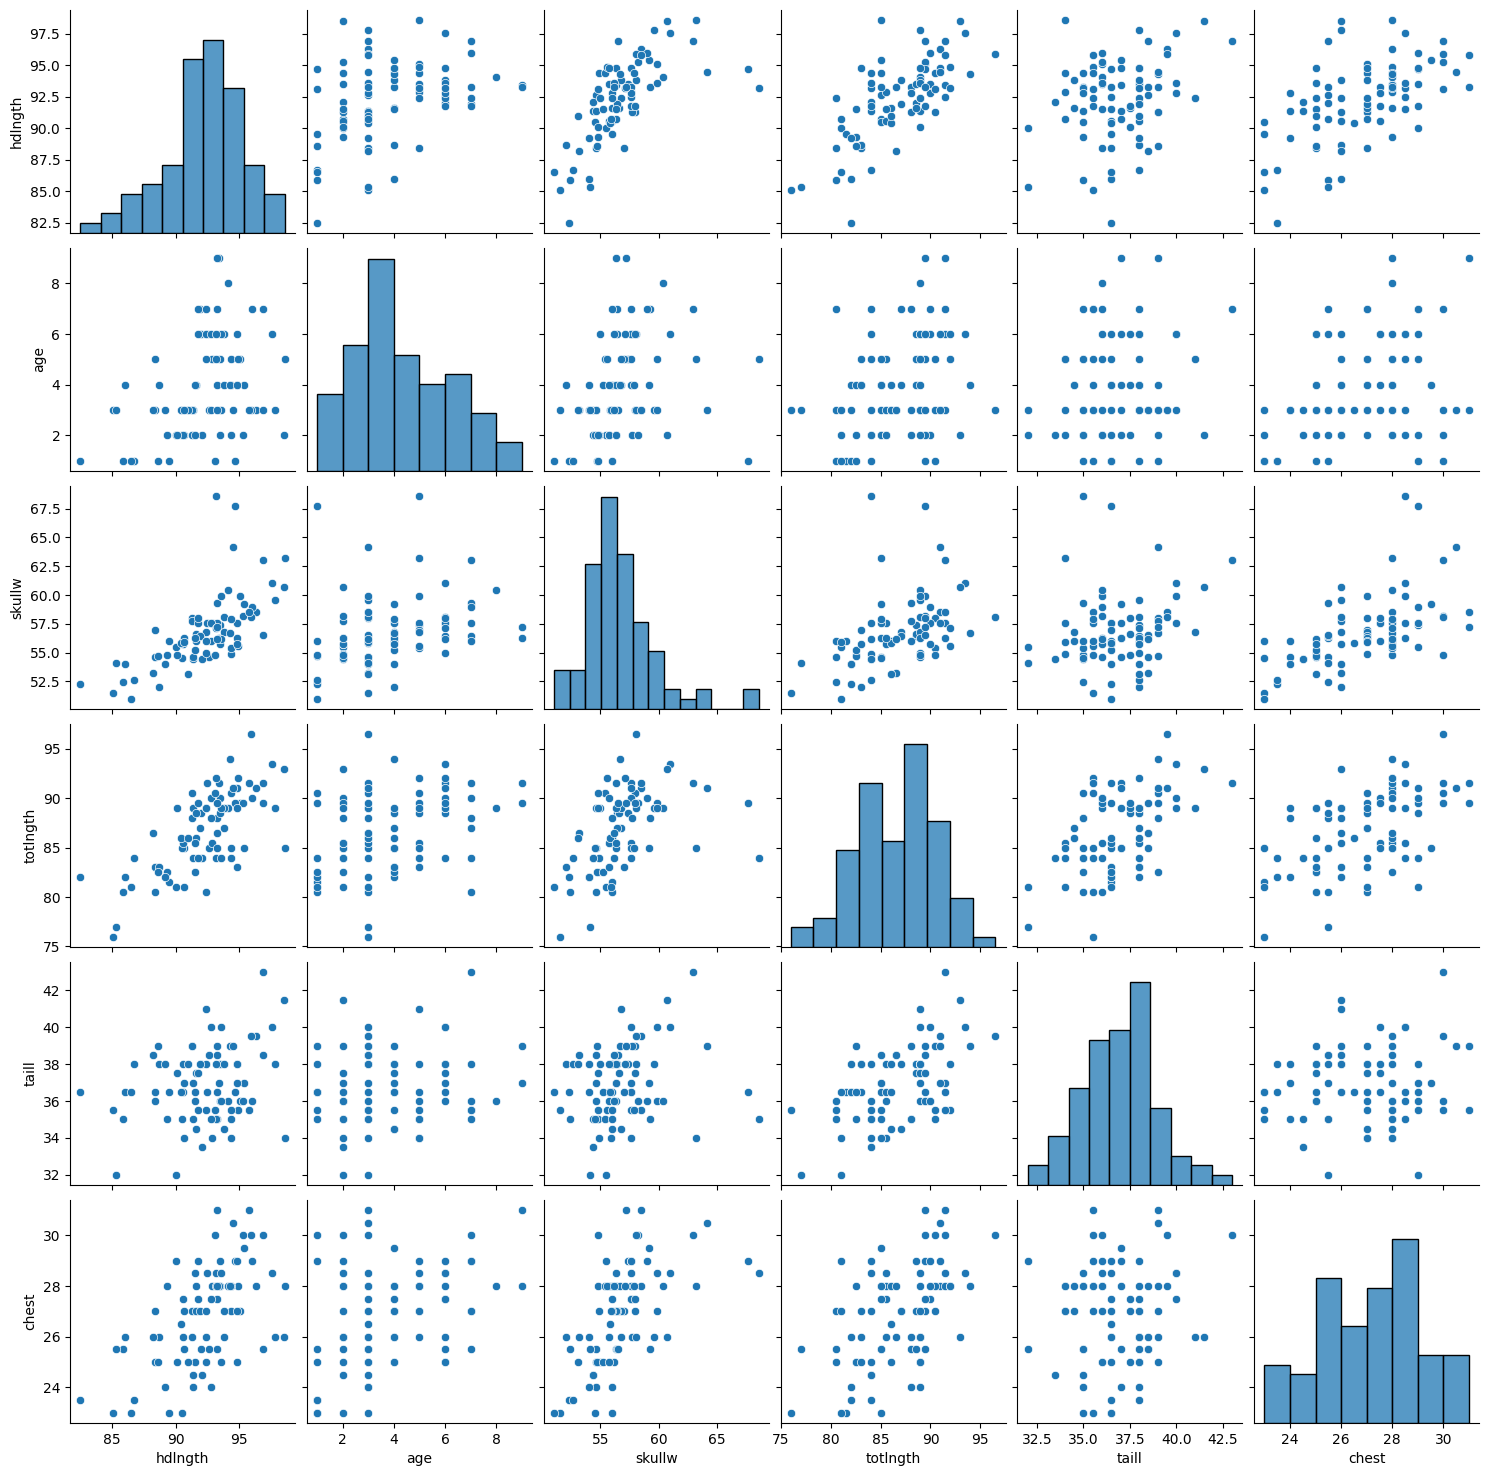

<Axes: >

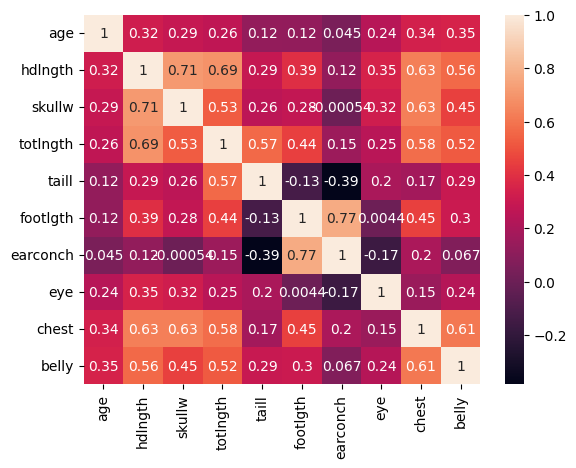

In [149]:
# Рассмотрим зависимость длины головы от других переменных с помощью парных графиков
sns.pairplot(
    pd.concat(
        [y_train,
         X_train[['age', 'skullw', 'totlngth', 'taill', 'chest']]], axis=1)
)
plt.show()
sns.heatmap(data.corr(numeric_only=True), annot=True)

## Проверим связь длины головы и возраста с помощью теста Пирсона

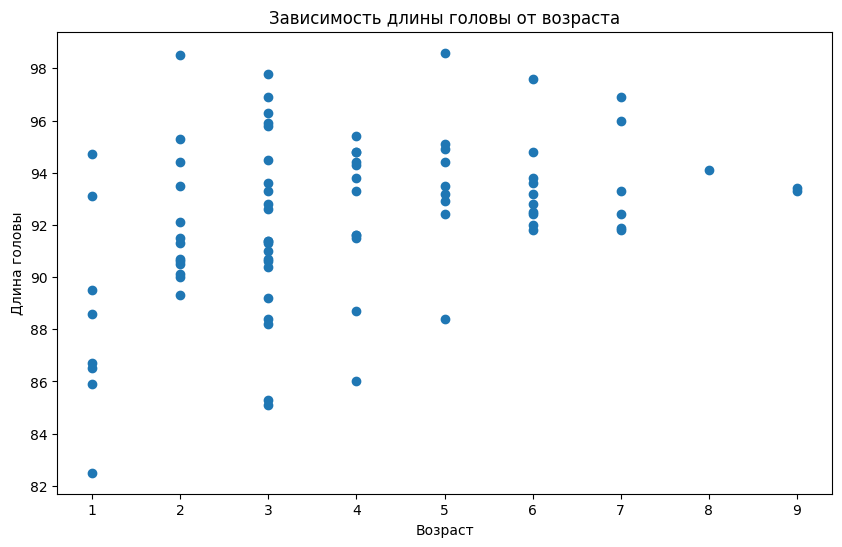

In [154]:
# Выведем график зависимости длины головы от возраста
plt.figure(figsize=(10, 6))
plt.scatter(X_train['age'], y_train)
plt.title('Зависимость длины головы от возраста')
plt.xlabel('Возраст')
plt.ylabel('Длина головы')
plt.show()

Проверим на нормальность распределения переменных с помощью теста Жарка-Бера, так как тест Пирсона требует нормальности данных.
В тесте Жарка-Бера:
- Нулевая гипотеза (H0): Данные распределены нормально
- Альтернативная гипотеза (H1): Данные не распределены нормально
- Уровень значимости (alpha): 0.05

In [ ]:
# Тест Жарка-Бера для проверки нормальности распределения возраста
_, jb_p_value = stats.jarque_bera(X_train['age'])
print(f"p-value для теста Жарка-Бера для возраста: {jb_p_value:.4f}")

In [151]:
# Тест Жарка-Бера для проверки нормальности распределения длины головы
_, jb_p_value = stats.jarque_bera(y_train)
print(f"p-value для теста Жарка-Бера для длины головы: {jb_p_value:.4f}")

p-value для теста Жарка-Бера для размера живота: 0.0652


Результаты теста Жарка–Бера не дают оснований отвергнуть гипотезу
о нормальности распределений переменных. Следовательно,
использование параметрического критерия Пирсона является допустимым.

Теперь проведем тест Пирсона для проверки корреляции между возрастом и длиной головы. В тесте Пирсона:
- Нулевая гипотеза (H0): Между возрастом и длиной головы нет корреляции
- Альтернативная гипотеза (H1): Между возрастом и длиной головы есть корреляция
- Уровень значимости (alpha): 0.05

Формула для расчёта коэффициента корреляции Пирсона (r) между двумя переменными X и Y:
$$
r = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2} \sqrt{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}}
$$
Далее, для проверки статистической значимости корреляции, мы можем использовать t-статистику, которая рассчитывается следующим образом:
$$
t = r \sqrt{\frac{n - 2}{1 - r^2}}
$$
где n - количество наблюдений. При условии H0, t-статистика распределяется по t-распределению с n-2 степенями свободы.

In [155]:
# Тест Пирсона для проверки корреляции между возрастом и длиной головы
pearson_corr, pearson_p_value = stats.pearsonr(X_train['age'], y_train)
print(f"Коэффициент корреляции Пирсона: {pearson_corr:.4f}, p-value: {pearson_p_value:.4f}")

Коэффициент корреляции Пирсона: 0.3633, p-value: 0.0007


In [158]:
# Вручную реализуем тест Пирсона
def pearson_test_manual(x, y, alpha=0.05):
    n = len(x)
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    up = np.sum((x - mean_x) * (y - mean_y))
    down = np.sqrt(np.sum((x - mean_x) ** 2) * np.sum((y - mean_y) ** 2))

    r = up / down
    t = r * np.sqrt((n - 2) / (1 - r ** 2))

    critical_value = stats.t.ppf(1 - alpha / 2, df=n - 2)
    p_value = 2 * (1 - stats.t.cdf(abs(t), df=n - 2))
    print(
        f"Коэффициент корреляции Пирсона: {r:.4f}, t-статистика: {t:.4f}, критическое значение: {critical_value:.4f}, p-value: {p_value:.4f}")


pearson_test_manual(X_train['age'], y_train)

Коэффициент корреляции Пирсона: 0.3633, t-статистика: 3.5094, критическое значение: 1.9897, p-value: 0.0007


Значения тестов совпадают, значит функция реализована верно. Результат говорит о том, что мы должно что мы отвергаем нулевую гипотезу о том, что между возрастом и длиной головы нет корреляции, так как p-value для теста Пирсона ниже стандартного уровня значимости 0.05. Коэффициент корреляции Пирсона показывает 0.36 - умеренную положительную корреляцию между возрастом и длиной головы, что означает, что с увеличением возраста длина головы имеет тенденцию увеличиваться.

## Проверка связи размера живота и размера ушной раковины (earconch)

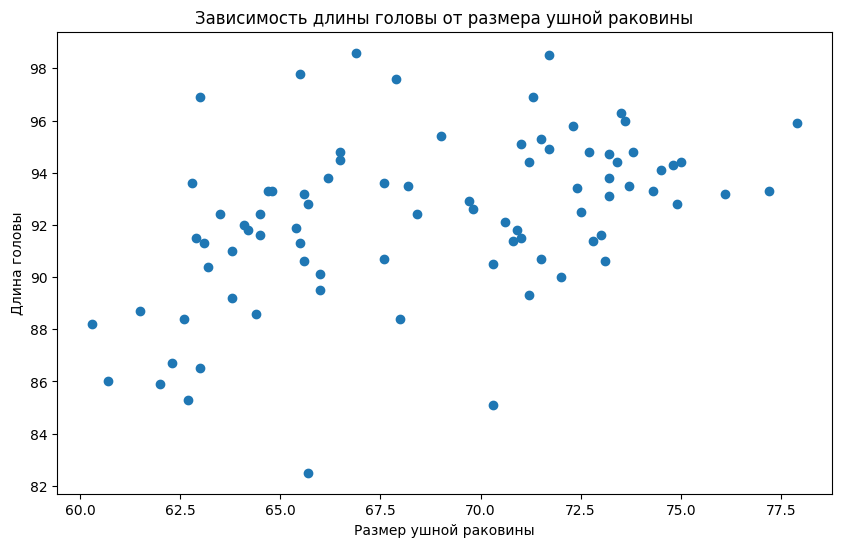

In [178]:
# Выведем график зависимости длины головы от размера ушной раковины
plt.figure(figsize=(10, 6))
plt.scatter(X_train['earconch'], y_train)
plt.title('Зависимость длины головы от размера ушной раковины')
plt.xlabel('Размер ушной раковины')
plt.ylabel('Длина головы')
plt.show()

In [179]:
# Число наблюдений
n = len(X_train)
# Число уникальных наблюдений длин головы и размера ушной раковины
unique_observations_earconch = len(X_train['earconch'].unique())
unique_observations_hdlngth = len(y_train.unique())
print(
    f"Число наблюдений: {n}, Число уникальных наблюдений размера ушной раковины: {unique_observations_earconch}, Число уникальных наблюдений длины головы: {unique_observations_hdlngth}"
)

Число наблюдений: 83, Число уникальных наблюдений размера ушной раковины: 56, Число уникальных наблюдений длины головы: 60


https://math.semestr.ru/corel/kendel.php

Поскольку в данных присутствуют повторяющиеся значения, используем скорректированный
коэффициент Кенделла ($tau_b$), который учитывает наличие связных рангов. В тесте Кенделла:
- Нулевая гипотеза (H0): Между размером ушной раковины и длиной головы нет монотонной зависимости
- Альтернативная гипотеза (H1): Между размером ушной раковины и длиной головы есть монотонная зависимость
- Уровень значимости (alpha): 0.05

Скорректированный коэффициент Кенделла ($tau_b$) рассчитывается по формуле:
$$
\tau_b = \frac{P - Q}{\sqrt{(n_0 - n_x)(n_0 - n_y)}}
$$
где:
- $P$ - количество пар наблюдений, которые согласованы
- $Q$ - количество пар наблюдений, которые не согласованы
- $n_0 = \frac{n(n-1)}{2}$ - общее количество пар наблюдений
- $n_x = \frac{1}{2} \sum_{i}^k t_i^x(t_i^x - 1)$ - поправка на связные ранги в переменной x, i - номер группы связей
- $n_y = \frac{1}{2} \sum_{j}^m t_j^y(t_j^y - 1)$ - поправка на связные ранги в переменной y, j - номер группы связей
- $t_i^x$ - количество наблюдений в i-й группе связей для переменной x
- $t_j^y$ - количество наблюдений в j-й группе связей для переменной y

Статистика теста Кенделла рассчитывается следующим образом:
$$
z = \frac{\tau_b}{\sqrt{\frac{2(2n +5)}{9n(n-1)}}}
$$
При условии H0, z-статистика распределяется по стандартному нормальному распределению.

In [188]:
# Тест Кенделла для проверки монотонной зависимости между размером ушной раковины и длиной головы
kendall_corr, kendall_p_value = stats.kendalltau(X_train['earconch'], y_train)
print(f"Коэффициент Кенделла: {kendall_corr:.4f}, p-value: {kendall_p_value:.4f}")

Коэффициент Кенделла: 0.2151, p-value: 0.0043


In [194]:
# Вручную реализуем тест Кенделла
def kendall_tau_b_manual(x, y, alpha=0.05):
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)

    P = 0
    Q = 0
    n_x = 0
    n_y = 0
    for i in range(n):
        for j in range(i + 1, n):
            if (x[i] < x[j] and y[i] < y[j]) or (x[i] > x[j] and y[i] > y[j]):
                P += 1
            elif (x[i] < x[j] and y[i] > y[j]) or (x[i] > x[j] and y[i] < y[j]):
                Q += 1
            if x[i] == x[j]:
                n_x += 1
            if y[i] == y[j]:
                n_y += 1
    n_0 = n * (n - 1) / 2
    tau_b = (P - Q) / np.sqrt((n_0 - n_x) * (n_0 - n_y))
    z = tau_b / np.sqrt(2 * (2 * n + 5) / (9 * n * (n - 1)))
    critical_value = stats.norm.ppf(1 - alpha / 2)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    print(
        f"Коэффициент Кенделла: {tau_b:.4f}, z-статистика: {z:.4f}, критическое значение: {critical_value:.4f}, p-value: {p_value:.4f}"
    )


kendall_tau_b_manual(X_train['earconch'], y_train)

Коэффициент Кенделла: 0.2151, z-статистика: 2.8783, критическое значение: 1.9600, p-value: 0.0040


Значения тестов совпадают, значит функция реализована верно. Результат говорит о том, что мы отвергаем нулевую гипотезу о том, что между размером ушной раковины и длиной головы нет монотонной зависимости, так как p-value для теста Кенделла ниже стандартного уровня значимости 0.05. Коэффициент Кенделла показывает 0.22 - слабую положительную монотонную зависимость между размером ушной раковины и длиной головы, что означает, что с увеличением размера ушной раковины длина головы имеет тенденцию увеличиваться.